# RGB Tone Extraction v3 (Deep 레벨 추가 + 희귀 톤 통합)

### 최종 톤 구성
| 구분 | 내용 |
|---|---|
| 무채색 | White / Light-Gray / Medium-Gray / Dark-Gray / Black (5종) |
| 유채색 레벨 | Dark / Dull / Soft / **Deep** / Light (5종) |
| 유채색 계열 | Red / Orange / Yellow / Green / Sky-Blue / Blue (6종, 희귀 병합 후) |
| **최대 합계** | **5 + 30 = 35종** |

> **v2 → v3 변경점**
> 1. `Deep` 레벨 추가: 고채도+중간명도(진한 색) 오분류 수정 (`#80533A` 갈색 → Deep-Orange)
> 2. `TONE_MERGE` 전면 재작성: Deep 변형 추가 + 희귀 톤(rows < 50) 통합


## 0. 드라이브 연결 & 데이터 로드

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DARTB/housewarming_cover_image_colors_final_v3.csv')
print(f"로드 완료: {len(df):,}행")
print(df.columns.tolist())

Mounted at /content/drive
로드 완료: 8,000행
['contentId', 'coverImageUrl', 'color1_r', 'color1_g', 'color1_b', 'color1_hex', 'color1_ratio', 'color2_r', 'color2_g', 'color2_b', 'color2_hex', 'color2_ratio', 'color3_r', 'color3_g', 'color3_b', 'color3_hex', 'color3_ratio', 'color4_r', 'color4_g', 'color4_b', 'color4_hex', 'color4_ratio', 'color5_r', 'color5_g', 'color5_b', 'color5_hex', 'color5_ratio']


In [ ]:
import colorsys
import math
from io import BytesIO

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import requests
from IPython.display import display
from PIL import Image

## 1. RGB → 톤 변환 함수

In [ ]:
# ── RGB → HSV → Tone 변환 함수 ──────────────────────────────────────
#
# 톤 레벨 5종
# ┌─────────────────────────────────────────────────────────┐
# │  Dark : v < 40              어두운 색 (채도 무관)        │
# │  Dull : s < 40, v < 65      탁한 중간 명도 (저채도)      │
# │  Soft : s < 40, v >= 65     밝은 파스텔 (저채도)         │
# │  Deep : s >= 40, v < 65     진한 색 (고채도+중간 명도)   │  ← v2에서 신규
# │  Light: s >= 40, v >= 65    선명하고 밝은 색 (고채도)    │
# └─────────────────────────────────────────────────────────┘

def get_color_family(h):
    """H(도, 0~360) → 색상 계열명 (11종, 병합 전)"""
    if   h < 15:  return 'Red'
    elif h < 35:  return 'Orange'
    elif h < 65:  return 'Yellow'
    elif h < 80:  return 'Yellow-Green'   # 병합 대상
    elif h < 150: return 'Green'
    elif h < 175: return 'Cyan'           # 병합 대상
    elif h < 210: return 'Sky-Blue'
    elif h < 255: return 'Blue'
    elif h < 290: return 'Blue-Purple'    # 병합 대상
    elif h < 330: return 'Purple'
    elif h < 345: return 'Red-Purple'     # 병합 대상
    else:         return 'Red'

def get_tone_level(s, v):
    """S, V(0~100) → 톤 레벨 5종"""
    if v < 40:
        return 'Dark'
    elif s < 40:
        return 'Dull' if v < 65 else 'Soft'
    else:                         # s >= 40
        return 'Deep' if v < 65 else 'Light'

def hsv_to_tone(h, s, v):
    """HSV → 최종 톤 문자열"""
    if s < 15:                    # 무채색 (채도 15 미만)
        if   v >= 85: return 'White'
        elif v >= 65: return 'Light-Gray'
        elif v >= 45: return 'Medium-Gray'
        elif v >= 25: return 'Dark-Gray'
        else:         return 'Black'
    return f"{get_tone_level(s, v)}-{get_color_family(h)}"

def rgb_to_hsv(r, g, b):
    h, s, v = colorsys.rgb_to_hsv(r / 255, g / 255, b / 255)
    return round(h * 360, 1), round(s * 100, 1), round(v * 100, 1)

def rgb_to_tone(r, g, b):
    return hsv_to_tone(*rgb_to_hsv(r, g, b))

# ── 검증 ─────────────────────────────────────────────────────────────
tests = [
    (255, 0,   0,   'Light-Red'),       # 순수 빨강    S=100 V=100 → Light ✅
    (128, 30,  30,  'Deep-Red'),        # 진한 빨강    S=76  V=50  → Deep ✅
    (0,   0,   0,   'Black'),           # 검정               V=0   ✅
    (255, 255, 255, 'White'),           # 흰색               V=100 ✅
    (30,  30,  90,  'Dark-Blue'),       # 어두운 파랑  V=35        → Dark ✅
    (160, 130, 100, 'Dull-Orange'),     # 탁한 베이지  S=37  V=62  → Dull ✅
    (128, 100, 85,  'Dull-Orange'),     # 탁한 갈색    S=33  V=50  → Dull ✅
    (180, 210, 240, 'Soft-Sky-Blue'),   # 파스텔 하늘  S=25  V=94  → Soft ✅
    (0,   100, 200, 'Light-Blue'),      # 선명 파랑    S=100 V=78  → Light ✅
    (0x80,0x53,0x3A,'Deep-Orange'),     # 문제 색 #80533A H=21 S=55 V=50 → Deep ✅
]
print("검증 결과:")
all_ok = True
for r, g, b, expected in tests:
    result = rgb_to_tone(r, g, b)
    h, s, v = rgb_to_hsv(r, g, b)
    ok = result == expected
    if not ok: all_ok = False
    print(f"  RGB({r:3},{g:3},{b:3}) H={h:5.1f} S={s:5.1f} V={v:5.1f}  →  {result:20s}  {'✅' if ok else '❌ expected '+expected}")
print(f"\n{'✅ 전체 통과' if all_ok else '❌ 일부 실패'}")

검증 결과:
  RGB(255,  0,  0) H=  0.0 S=100.0 V=100.0  →  Light-Red             ✅
  RGB(128, 30, 30) H=  0.0 S= 76.6 V= 50.2  →  Deep-Red              ✅
  RGB(  0,  0,  0) H=  0.0 S=  0.0 V=  0.0  →  Black                 ✅
  RGB(255,255,255) H=  0.0 S=  0.0 V=100.0  →  White                 ✅
  RGB( 30, 30, 90) H=240.0 S= 66.7 V= 35.3  →  Dark-Blue             ✅
  RGB(160,130,100) H= 30.0 S= 37.5 V= 62.7  →  Dull-Orange           ✅
  RGB(128,100, 85) H= 20.9 S= 33.6 V= 50.2  →  Dull-Orange           ✅
  RGB(180,210,240) H=210.0 S= 25.0 V= 94.1  →  Soft-Blue             ❌ expected Soft-Sky-Blue
  RGB(  0,100,200) H=210.0 S=100.0 V= 78.4  →  Light-Blue            ✅
  RGB(128, 83, 58) H= 21.4 S= 54.7 V= 50.2  →  Deep-Orange           ✅

❌ 일부 실패


## 2. df → all_colors 생성

In [ ]:
# ── df → all_colors (long format) ───────────────────────────────────
pieces = []
for i in range(1, 6):
    tmp = df[['contentId',
              f'color{i}_r', f'color{i}_g', f'color{i}_b',
              f'color{i}_hex', f'color{i}_ratio']].copy()
    tmp.columns = ['contentId', 'r', 'g', 'b', 'hex', 'ratio']
    tmp['color_rank'] = i
    pieces.append(tmp)

all_colors = pd.concat(pieces, ignore_index=True).dropna(subset=['r', 'g', 'b'])
all_colors[['r', 'g', 'b']] = all_colors[['r', 'g', 'b']].astype(int)

# raw 톤 계산 (병합 전)
all_colors['tone'] = all_colors.apply(
    lambda row: rgb_to_tone(row['r'], row['g'], row['b']), axis=1
)

print(f"all_colors: {len(all_colors):,}행 / {all_colors['contentId'].nunique():,}개 게시글")
print(f"raw tone 종류: {all_colors['tone'].nunique()}개")
print("\n상위 20개:")
print(all_colors['tone'].value_counts().head(20))

all_colors: 40,000행 / 8,000개 게시글
raw tone 종류: 54개

상위 20개:
tone
Light-Gray           9782
Medium-Gray          5079
White                4359
Dark-Orange          4077
Dull-Orange          3603
Dark-Yellow          1769
Dull-Yellow          1756
Dark-Gray            1719
Soft-Orange          1713
Black                1192
Deep-Orange          1044
Soft-Yellow           848
Dark-Red              387
Soft-Sky-Blue         361
Light-Orange          306
Dark-Green            236
Dark-Blue             216
Dark-Sky-Blue         201
Deep-Yellow           176
Dark-Yellow-Green     164
Name: count, dtype: int64


In [ ]:
# ── 헬퍼 함수 ────────────────────────────────────────────────────────
def normalize_hex(hex_value):
    if pd.isna(hex_value):
        return None
    value = str(hex_value).strip().upper()
    if not value:
        return None
    if not value.startswith('#'):
        value = f'#{value}'
    if len(value) == 4:
        value = '#' + ''.join(ch * 2 for ch in value[1:])
    return value

def join_unique(values, max_items=8):
    uniq = [str(v) for v in pd.unique(values) if pd.notna(v)]
    if len(uniq) <= max_items:
        return ', '.join(uniq)
    return ', '.join(uniq[:max_items]) + f' ... (+{len(uniq) - max_items})'

all_colors['hex'] = all_colors['hex'].map(normalize_hex)

## 3. TONE_MERGE

In [ ]:
# ── TONE_MERGE ───────────────────────────────────────────────────────
# 두 가지 목적:
# [A] 색상 계열 통합: Yellow-Green / Cyan / Blue-Purple / Red-Purple → 인접 계열로 흡수
# [B] 희귀 톤 통합 : rows 가 적어 분석 의미 없는 톤 → 가장 가까운 계열로 병합
#
# ※ 체인 방지: 'Dull-Blue' 가 Soft-Blue로 병합되므로,
#   Dull-Blue로 향하는 규칙은 직접 Soft-Blue로 지정

TONE_MERGE = {

    # ── [A] 색상 계열 통합 ─────────────────────────────────────────────

    # Yellow-Green → Green / Yellow
    'Dark-Yellow-Green':   'Dark-Green',
    'Dull-Yellow-Green':   'Dull-Green',
    'Soft-Yellow-Green':   'Soft-Yellow',
    'Deep-Yellow-Green':   'Deep-Green',
    'Light-Yellow-Green':  'Light-Green',

    # Cyan → Blue(어두운) / Sky-Blue(밝은)
    'Dark-Cyan':           'Dark-Blue',
    'Dull-Cyan':           'Soft-Blue',      # Dull-Blue가 Soft-Blue로 병합되므로 직접 지정
    'Soft-Cyan':           'Soft-Sky-Blue',
    'Deep-Cyan':           'Deep-Sky-Blue',
    'Light-Cyan':          'Light-Sky-Blue',

    # Blue-Purple → Blue
    'Dark-Blue-Purple':    'Dark-Blue',
    'Dull-Blue-Purple':    'Soft-Blue',      # 동상
    'Soft-Blue-Purple':    'Soft-Blue',
    'Deep-Blue-Purple':    'Deep-Blue',
    'Light-Blue-Purple':   'Light-Blue',

    # Red-Purple → Red(어두운) / 나머지 Light-Red
    'Dark-Red-Purple':     'Dark-Red',
    'Dull-Red-Purple':     'Dull-Red',
    'Soft-Red-Purple':     'Light-Red',
    'Deep-Red-Purple':     'Deep-Red',
    'Light-Red-Purple':    'Light-Red',

    # ── [B] 희귀 톤 통합 (rows 기준, 데이터 실행 후 재확인 가능) ────────

    'Dull-Blue':           'Soft-Blue',      # 극소 rows → Soft-Blue
    'Soft-Red':            'Light-Red',      # 극소 rows → Light-Red
    'Dark-Purple':         'Dark-Blue',      # 극소 rows → Dark-Blue
    'Soft-Green':          'Light-Green',    # 극소 rows → Light-Green
    'Dull-Purple':         'Soft-Blue',      # 극소 rows → Soft-Blue
    'Light-Purple':        'Soft-Sky-Blue',  # 극소 rows → Soft-Sky-Blue
    'Soft-Purple':         'Soft-Blue',      # 극소 rows → Soft-Blue
}

all_colors['raw_tone'] = all_colors['tone']
all_colors['tone']     = all_colors['raw_tone'].map(lambda t: TONE_MERGE.get(t, t))

# ── 병합 감사 ─────────────────────────────────────────────────────────
merge_audit = (
    all_colors.groupby(['raw_tone', 'tone'], as_index=False)
    .agg(n_rows=('raw_tone', 'size'), ratio_sum=('ratio', 'sum'))
    .sort_values(['tone', 'n_rows'], ascending=[True, False])
)
merge_audit['changed'] = merge_audit['raw_tone'] != merge_audit['tone']

print(f"병합 전: {all_colors['raw_tone'].nunique()}종")
print(f"병합 후: {all_colors['tone'].nunique()}종")
print("\n[실제로 효과 있는 병합 항목]")
display(merge_audit[merge_audit['changed']].reset_index(drop=True))

병합 전: 54종
병합 후: 32종

[실제로 효과 있는 병합 항목]


,raw_tone,tone,n_rows,ratio_sum,changed
0,Dark-Cyan,Dark-Blue,87,10.7777,True
1,Dark-Purple,Dark-Blue,22,2.1142,True
2,Dark-Blue-Purple,Dark-Blue,20,2.1791,True
3,Dark-Yellow-Green,Dark-Green,164,18.7999,True
4,Dark-Red-Purple,Dark-Red,12,1.3521,True
5,Deep-Yellow-Green,Deep-Green,11,2.4127,True
6,Deep-Cyan,Deep-Sky-Blue,6,0.4976,True
7,Dull-Yellow-Green,Dull-Green,39,7.8285,True
8,Dull-Red-Purple,Dull-Red,5,0.6886,True
9,Light-Blue-Purple,Light-Blue,1,0.1330,True


## 4. 톤 요약

In [ ]:
# ── 톤 요약 ──────────────────────────────────────────────────────────
tone_summary = (
    all_colors.groupby('tone', as_index=False)
    .agg(
        n_rows       = ('tone', 'size'),
        n_hex        = ('hex', 'nunique'),
        source_tones = ('raw_tone', join_unique),
    )
    .sort_values(['n_rows', 'tone'], ascending=[False, True])
    .reset_index(drop=True)
)

hex_tone_dict = (
    all_colors.groupby('hex')['tone']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'tone': 'tone_name'})
)

print(f"최종 tone 종류: {all_colors['tone'].nunique()}개\n")
display(tone_summary)

최종 tone 종류: 32개



,tone,n_rows,n_hex,source_tones
0,Light-Gray,9782,7483,Light-Gray
1,Medium-Gray,5079,4077,Medium-Gray
2,White,4359,3396,White
3,Dark-Orange,4077,3591,Dark-Orange
4,Dull-Orange,3603,3136,Dull-Orange
5,Dark-Yellow,1769,1577,Dark-Yellow
6,Dull-Yellow,1756,1561,Dull-Yellow
7,Dark-Gray,1719,1530,Dark-Gray
8,Soft-Orange,1713,1602,Soft-Orange
9,Black,1192,949,Black


## 5. contentId → 대표 톤 (ratio 가중합산)

In [ ]:
# ── contentId별 대표 톤 ──────────────────────────────────────────────
tone_weight = (
    all_colors.groupby(['contentId', 'tone'])['ratio']
    .sum()
    .reset_index()
)

top1 = (
    tone_weight.sort_values('ratio', ascending=False)
    .groupby('contentId').nth(0)
    .reset_index()
    .rename(columns={'tone': 'primary_tone', 'ratio': 'primary_ratio'})
)
top2 = (
    tone_weight.sort_values('ratio', ascending=False)
    .groupby('contentId').nth(1)
    .reset_index()
    .rename(columns={'tone': 'secondary_tone', 'ratio': 'secondary_ratio'})
)

content_tone = top1.merge(top2, on='contentId', how='left')
content_tone['primary_ratio']   = content_tone['primary_ratio'].round(3)
content_tone['secondary_ratio'] = content_tone['secondary_ratio'].round(3)

print(f"완료: {len(content_tone):,}개 게시글")
print(f"primary_tone 종류: {content_tone['primary_tone'].nunique()}개")
display(content_tone.head(10))

완료: 8,000개 게시글
primary_tone 종류: 32개


,index_x,contentId,primary_tone,primary_ratio,index_y,secondary_tone,secondary_ratio
0,27999,173486,Light-Gray,0.953,28000,Medium-Gray,0.030
1,14780,145477,Light-Gray,0.949,14781,Medium-Gray,0.045
2,12315,140996,Light-Gray,0.942,12317,White,0.046
3,10513,137263,Light-Gray,0.942,10515,White,0.036
4,27288,171367,Light-Gray,0.935,27289,Medium-Gray,0.042
5,25880,167691,Light-Gray,0.931,25881,Medium-Gray,0.053
6,11742,139781,Light-Gray,0.927,11741,Dull-Yellow,0.046
7,11669,139605,Medium-Gray,0.927,11668,Light-Gray,0.046
8,25036,165851,Light-Gray,0.927,25037,Medium-Gray,0.061
9,2275,99277,Light-Gray,0.923,2274,Dull-Orange,0.063


## 6. 톤 사전 시각화

/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 53441 (\N{HANGUL SYLLABLE TAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7755/2165019297.py:79: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

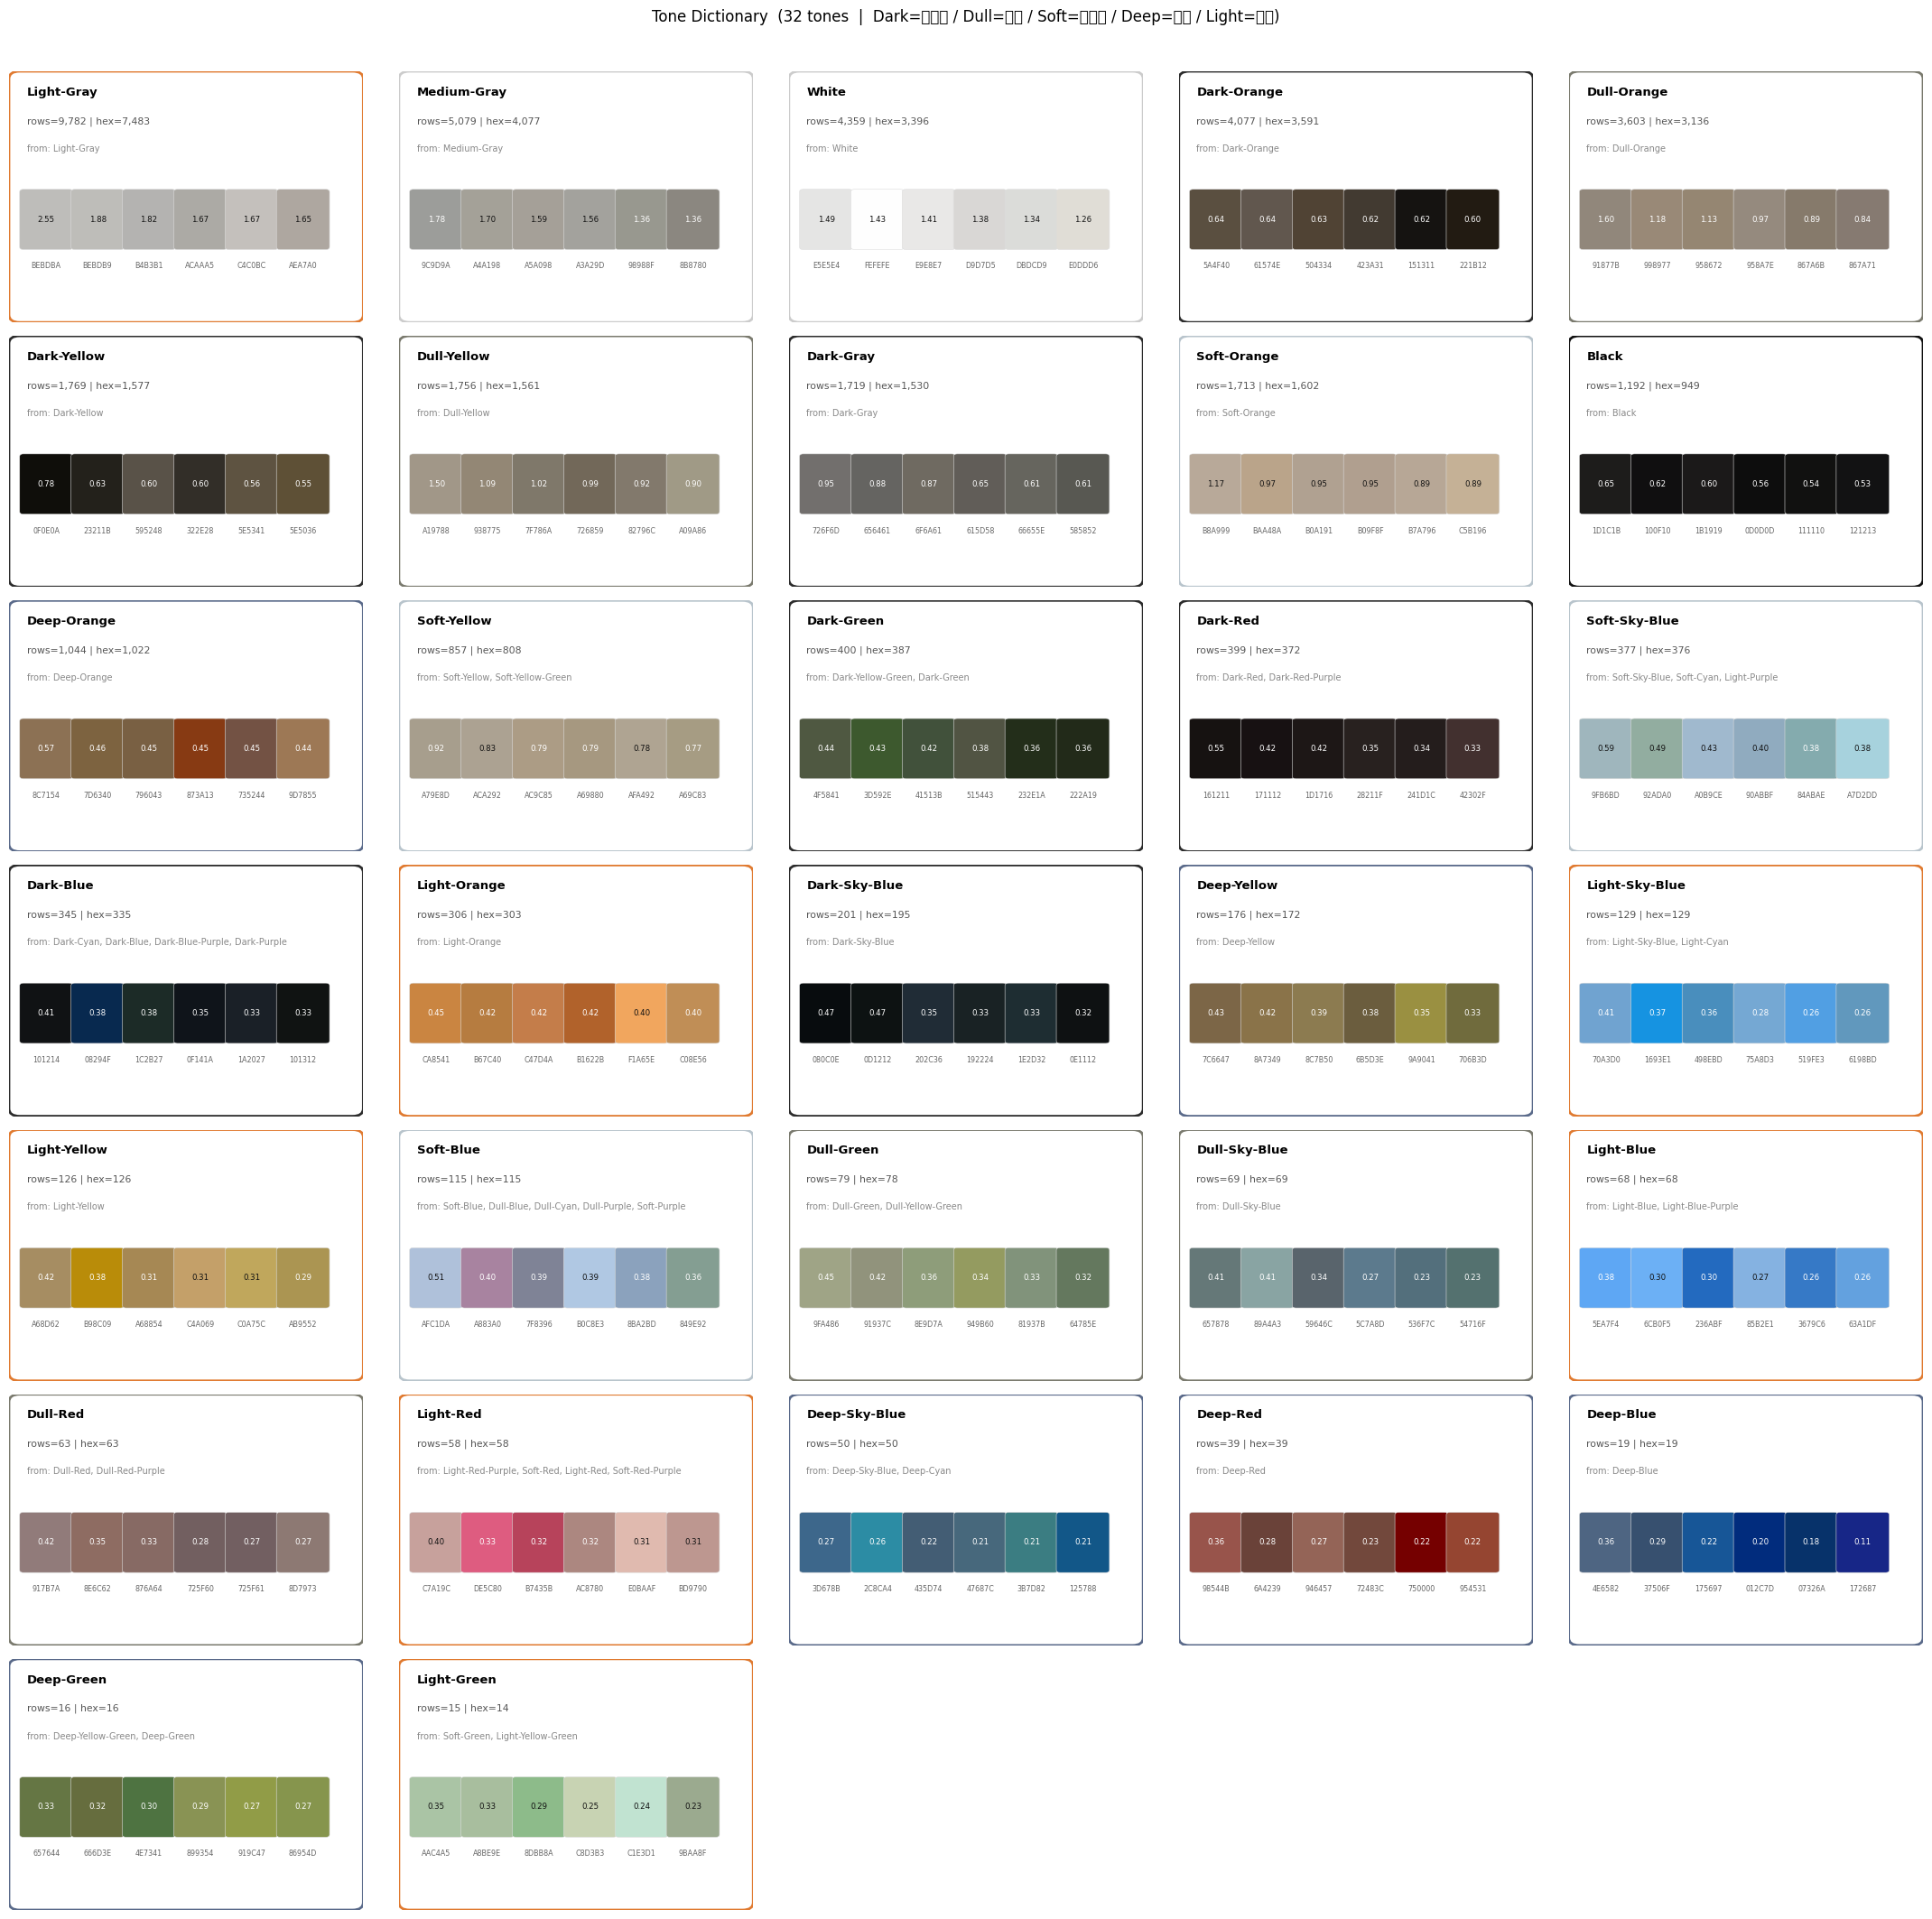

In [ ]:
def hex_to_rgb(hex_color):
    hc = normalize_hex(hex_color) or '#888888'
    return tuple(int(hc[i:i+2], 16) for i in (1, 3, 5))

def ideal_text_color(hex_color):
    r, g, b = hex_to_rgb(hex_color)
    return '#111111' if (0.299*r + 0.587*g + 0.114*b) > 160 else '#FFFFFF'

# ── 톤별 대표 HEX ─────────────────────────────────────────────────────
tone_hex_rank = (
    all_colors.groupby(['tone', 'hex'], as_index=False)
    .agg(n_rows=('hex', 'size'), ratio_sum=('ratio', 'sum'))
    .sort_values(['tone', 'ratio_sum', 'n_rows'], ascending=[True, False, False])
)
SPT = 6   # samples per tone
top_hex    = tone_hex_rank.groupby('tone').head(SPT)
hex_map    = top_hex.groupby('tone')['hex'].apply(list).to_dict()
weight_map = top_hex.groupby('tone')['ratio_sum'].apply(list).to_dict()
meta_map   = tone_summary.set_index('tone').to_dict('index')

tone_list = tone_summary['tone'].tolist()
COLS = 5
ROWS = math.ceil(len(tone_list) / COLS)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 4.3, ROWS * 3.0))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.set_axis_off()

# 레벨별 헤더 색상 (카드 테두리 강조용)
LEVEL_COLOR = {
    'Dark' : '#2c2c2c',
    'Dull' : '#7a7a6e',
    'Soft' : '#b8c4cc',
    'Deep' : '#5a6a8a',
    'Light': '#e07a30',
    'White': '#cccccc', 'Light-Gray': '#aaaaaa',
    'Medium-Gray': '#888888', 'Dark-Gray': '#555555', 'Black': '#111111',
}

for ax, tone_name in zip(axes, tone_list):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    meta     = meta_map[tone_name]
    swatches = hex_map.get(tone_name, [])
    weights  = weight_map.get(tone_name, [])
    dom_hex  = swatches[0] if swatches else '#DDDDDD'
    level    = tone_name.split('-')[0]
    edge_col = LEVEL_COLOR.get(level, '#CCCCCC')

    ax.add_patch(patches.FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02,rounding_size=0.03',
        facecolor='#FFFFFF', edgecolor=edge_col, linewidth=2.0,
    ))
    ax.text(0.05, 0.94, tone_name, fontsize=9.5, fontweight='bold', va='top')
    ax.text(0.05, 0.82,
            f"rows={int(meta['n_rows']):,} | hex={int(meta['n_hex']):,}",
            fontsize=7.8, color='#555', va='top')
    ax.text(0.05, 0.71, f"from: {meta['source_tones']}",
            fontsize=7, color='#888', va='top')

    box_w = 0.13; gap = 0.015; y = 0.30
    for j, (hx, wt) in enumerate(zip(swatches, weights)):
        x = 0.04 + j * (box_w + gap)
        ax.add_patch(patches.FancyBboxPatch(
            (x, y), box_w, 0.22, boxstyle='round,pad=0.01',
            facecolor=hx, edgecolor='#DDD', linewidth=0.4,
        ))
        ax.text(x + box_w/2, y + 0.11, f"{wt:.2f}",
                ha='center', va='center', fontsize=6.2,
                color=ideal_text_color(hx))
        ax.text(x + box_w/2, y - 0.06, hx.replace('#', ''),
                ha='center', va='top', fontsize=5.8, color='#666')

fig.suptitle(
    f'Tone Dictionary  ({len(tone_list)} tones  |  Dark=어두운 / Dull=탁함 / Soft=파스텔 / Deep=진함 / Light=선명)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 7. contentId 검증 & 톤 상세 보기

In [ ]:
def inspect_one_tone(tone_name, top_n=24, cols=6):
    """특정 톤의 실제 hex 색상 상위 N개 시각화"""
    subset = (
        all_colors[all_colors['tone'] == tone_name]
        .groupby('hex', as_index=False)
        .agg(n_rows=('hex', 'size'), ratio_sum=('ratio', 'sum'))
        .sort_values(['ratio_sum', 'n_rows'], ascending=[False, False])
        .head(top_n)
    )
    if subset.empty:
        print(f'No rows for tone: {tone_name}')
        return

    rows = math.ceil(len(subset) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.1))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.set_axis_off()

    for ax, (_, s) in zip(axes, subset.iterrows()):
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.add_patch(patches.FancyBboxPatch(
            (0.10, 0.30), 0.80, 0.44, boxstyle='round,pad=0.02',
            facecolor=s['hex'], edgecolor='#CCC', linewidth=0.7,
        ))
        ax.text(0.5, 0.54, s['hex'],
                ha='center', va='center', fontsize=8,
                color=ideal_text_color(s['hex']))
        ax.text(0.5, 0.16,
                f"ratio={s['ratio_sum']:.3f}  rows={int(s['n_rows'])}",
                ha='center', va='center', fontsize=7.5, color='#555')

    fig.suptitle(f'Tone detail: {tone_name}  (top {len(subset)})', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

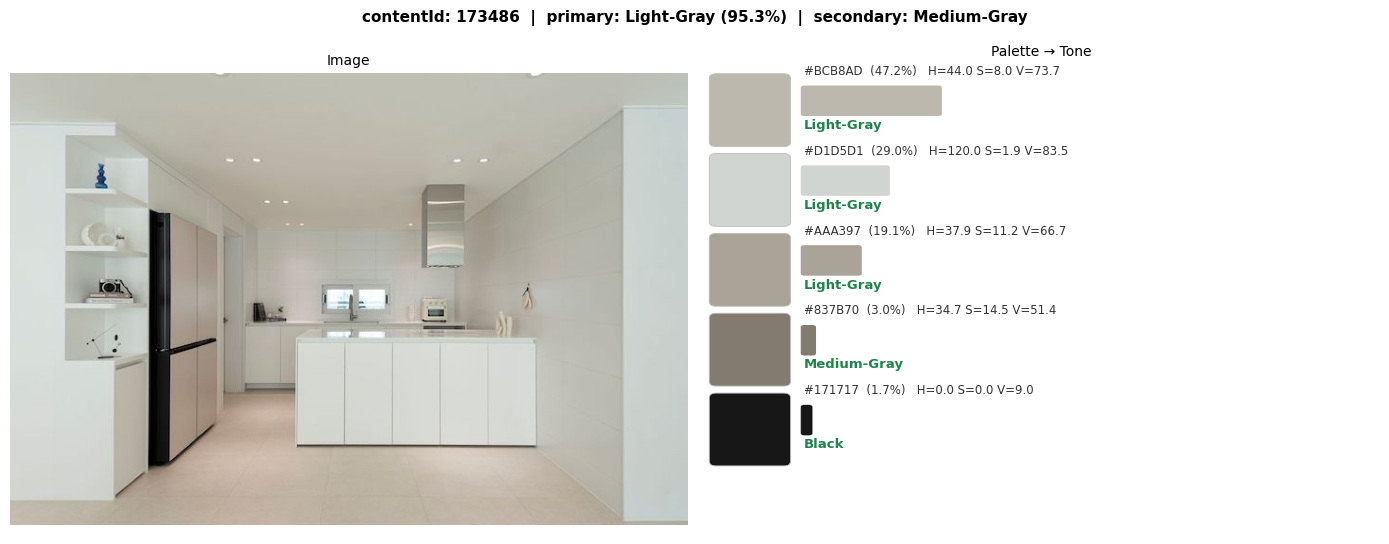

In [ ]:
def verify_image(content_id):
    """
    contentId 입력 → 커버 이미지 + color1~5 팔레트 시각화
    각 색상의 hex / H,S,V / raw_tone → merged_tone 표시
    """
    rows_df = df[df['contentId'] == content_id]
    if rows_df.empty:
        print(f"contentId {content_id} 없음"); return
    row = rows_df.iloc[0]

    ct_rows = content_tone[content_tone['contentId'] == content_id]
    if ct_rows.empty:
        print(f"content_tone에 {content_id} 없음"); return
    ct = ct_rows.iloc[0]

    tone_lookup = (
        all_colors[all_colors['contentId'] == content_id][['hex', 'raw_tone', 'tone']]
        .drop_duplicates()
    )

    # 이미지 로드
    img = None
    try:
        img = Image.open(BytesIO(
            requests.get(row['coverImageUrl'], timeout=8).content
        ))
    except Exception as e:
        print(f"이미지 로드 실패: {e}")

    n_colors = sum(1 for i in range(1, 6) if pd.notna(row.get(f'color{i}_r')))
    ncols_fig = 2 if img else 1
    fig, axes = plt.subplots(1, ncols_fig, figsize=(14 if img else 7, 5.5))
    if ncols_fig == 1:
        axes = [axes]

    fig.suptitle(
        f'contentId: {content_id}  |  '
        f'primary: {ct["primary_tone"]} ({ct["primary_ratio"]*100:.1f}%)  |  '
        f'secondary: {ct["secondary_tone"]}',
        fontsize=11, fontweight='bold'
    )

    if img:
        axes[0].imshow(img); axes[0].axis('off'); axes[0].set_title('Image', fontsize=10)
        ax_pal = axes[1]
    else:
        ax_pal = axes[0]

    ax_pal.axis('off'); ax_pal.set_xlim(0, 1); ax_pal.set_ylim(0, 1)
    ax_pal.set_title('Palette → Tone', fontsize=10)

    for i in range(1, n_colors + 1):
        r_v = int(row[f'color{i}_r'])
        g_v = int(row[f'color{i}_g'])
        b_v = int(row[f'color{i}_b'])
        hex_code = normalize_hex(row.get(f'color{i}_hex'))
        ratio    = row[f'color{i}_ratio']
        h_v, s_v, v_v = rgb_to_hsv(r_v, g_v, b_v)

        matched = tone_lookup[tone_lookup['hex'] == hex_code]
        if matched.empty:
            raw    = rgb_to_tone(r_v, g_v, b_v)
            merged = TONE_MERGE.get(raw, raw)
        else:
            raw    = matched.iloc[0]['raw_tone']
            merged = matched.iloc[0]['tone']

        y = 0.91 - (i - 1) * 0.17

        # 색상 스와치
        ax_pal.add_patch(patches.FancyBboxPatch(
            (0.02, y - 0.075), 0.10, 0.135,
            boxstyle='round,pad=0.01',
            facecolor=(r_v/255, g_v/255, b_v/255),
            edgecolor='#bbb', linewidth=0.6,
        ))
        # ratio 막대
        ax_pal.add_patch(patches.FancyBboxPatch(
            (0.15, y - 0.015), ratio * 0.42, 0.055,
            boxstyle='round,pad=0.005',
            facecolor=(r_v/255, g_v/255, b_v/255), edgecolor='none',
        ))
        # 상단: hex + ratio + HSV
        ax_pal.text(0.15, y + 0.075,
            f"{hex_code}  ({ratio*100:.1f}%)   H={h_v} S={s_v} V={v_v}",
            va='center', fontsize=8.5, color='#333')
        # 하단: raw → merged
        if raw != merged:
            label = f"{raw}  →  {merged}"
            color = '#1a5276'   # 파랑: 병합 발생
        else:
            label = f"{merged}"
            color = '#1e8449'   # 초록: 변경 없음
        ax_pal.text(0.15, y - 0.04, label,
            va='center', fontsize=9.5, fontweight='bold', color=color)

    plt.tight_layout()
    plt.show()

# ── 실행 ─────────────────────────────────────────────────────────────
verify_image(173486)

## 8. 저장 & 다운로드

In [ ]:
from google.colab import files

hex_tone_dict.to_csv('hex_tone_dict.csv', index=False)
content_tone.to_csv('content_tone.csv', index=False)

files.download('hex_tone_dict.csv')
files.download('content_tone.csv')

print(f"hex_tone_dict : {len(hex_tone_dict):,}행  (hex → tone_name)")
print(f"content_tone  : {len(content_tone):,}행  (contentId → primary/secondary_tone)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

hex_tone_dict : 33,716행  (hex → tone_name)
content_tone  : 8,000행  (contentId → primary/secondary_tone)
